In [59]:
import pandas as pd

In [60]:
business = pd.read_json(
    "../data/raw/yelp_academic_dataset_business.json",
    lines=True,
    nrows=5000
)

business.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [61]:
business.shape

(5000, 14)

In [62]:
business.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours'],
      dtype='object')

In [63]:
restaurants = business[
    business["categories"].str.contains("Restaurant", na=False)
]

restaurants.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,1,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '..."
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,0,"{'Caters': 'True', 'Alcohol': 'u'full_bar'', '...","Pubs, Restaurants, Italian, Bars, American (Tr...",None
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,1,"{'RestaurantsAttire': ''casual'', 'Restaurants...","Ice Cream & Frozen Yogurt, Fast Food, Burgers,...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '..."
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,1,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","Vietnamese, Food, Restaurants, Food Trucks","{'Monday': '11:0-14:0', 'Tuesday': '11:0-14:0'..."


In [64]:
restaurants.shape

(1762, 14)

In [65]:
restaurants.isnull().sum()

business_id       0
name              0
address           0
city              0
state             0
postal_code       0
latitude          0
longitude         0
stars             0
review_count      0
is_open           0
attributes       23
categories        0
hours           254
dtype: int64

In [66]:
restaurants["stars"].value_counts()

stars
4.0    463
3.5    395
4.5    281
3.0    257
2.5    162
2.0     85
1.5     61
5.0     49
1.0      9
Name: count, dtype: int64

In [67]:
restaurants["city"].value_counts().head(10)

city
Philadelphia    201
Indianapolis    111
Tampa           111
Nashville        97
New Orleans      92
Edmonton         77
Tucson           70
Saint Louis      51
Reno             46
Boise            27
Name: count, dtype: int64

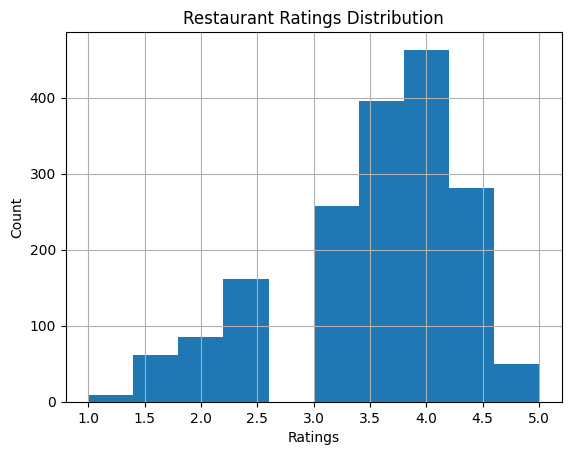

In [68]:
import matplotlib.pyplot as plt

restaurants["stars"].hist()

plt.xlabel("Ratings")
plt.ylabel("Count")
plt.title("Restaurant Ratings Distribution")

plt.show()

In [69]:
restaurants.isnull().sum()

business_id       0
name              0
address           0
city              0
state             0
postal_code       0
latitude          0
longitude         0
stars             0
review_count      0
is_open           0
attributes       23
categories        0
hours           254
dtype: int64

In [70]:
restaurants_cleaned = restaurants[
    [
        'business_id',
        'name',
        'city',
        'state',
        'latitude',
        'longitude',
        'stars',
        'review_count',
        'attributes',
        'categories'
    ]
]

In [71]:
restaurants_cleaned

,business_id,name,city,state,latitude,longitude,stars,review_count,attributes,categories
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,Philadelphia,PA,39.955505,-75.155564,4.0,80,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B..."
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,Ashland City,TN,36.269593,-87.058943,2.0,6,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea..."
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,Affton,MO,38.565165,-90.321087,3.0,19,"{'Caters': 'True', 'Alcohol': 'u'full_bar'', '...","Pubs, Restaurants, Italian, Bars, American (Tr..."
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,Nashville,TN,36.208102,-86.768170,1.5,10,"{'RestaurantsAttire': ''casual'', 'Restaurants...","Ice Cream & Frozen Yogurt, Fast Food, Burgers,..."
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,Tampa Bay,FL,27.955269,-82.456320,4.0,10,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","Vietnamese, Food, Restaurants, Food Trucks"
...,...,...,...,...,...,...,...,...,...,...
4980,HFuAKE0uZ-frIMjroeA-cA,SET NoLibs,Philadelphia,PA,39.967149,-75.140423,4.0,108,"{'Ambience': '{u'divey': False, u'hipster': Fa...","Mexican, Bars, Restaurants, Asian Fusion, Loun..."
4981,BmiBsrtq_fvMIsfWy75buQ,Dickey's BBQ Pit South,Reno,NV,39.409366,-119.750531,3.5,8,"{'Alcohol': 'u'none'', 'BusinessParking': '{'g...","Barbeque, Restaurants"
4983,digvt_7fV-AZFwt2Fp9Z-Q,Schnucks - Loughborough,Saint Louis,MO,38.557859,-90.261407,3.0,25,"{'RestaurantsPriceRange2': '2', 'BikeParking':...","Bakeries, Florists, Flowers & Gifts, Delis, Dr..."
4987,aqWE8jXPqIQ5Tt80gNmuSA,Taqueria Chazumba,Clearwater,FL,27.996878,-82.775358,3.5,12,"{'GoodForKids': 'True', 'BusinessAcceptsCredit...","Mexican, Restaurants"


In [72]:
restaurants_cleaned.duplicated(
    subset=['business_id']
).sum()

0

In [73]:
restaurants_cleaned['main_category'] = (
    restaurants_cleaned['categories']
    .str.split(',')
    .str[1]
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_20492\1843913069.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  restaurants_cleaned['main_category'] = (


In [74]:
restaurants_cleaned['main_category'] = (
    restaurants_cleaned['main_category']
    .str.strip()
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_20492\1618347434.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  restaurants_cleaned['main_category'] = (


In [75]:
restaurants_cleaned['city'].value_counts().head(15)

city
Philadelphia     201
Indianapolis     111
Tampa            111
Nashville         97
New Orleans       92
Edmonton          77
Tucson            70
Saint Louis       51
Reno              46
Boise             27
Santa Barbara     23
Franklin          19
Clearwater        18
Cherry Hill       17
Sparks            15
Name: count, dtype: int64

In [76]:
exclude_categories = [
    'Restaurants',
    'Food',
    'Bars',
    'Nightlife'
]

def extract_main_category(category_string):
    
    if pd.isna(category_string):
        return None

    categories = [cat.strip() for cat in category_string.split(',')]

    for cat in categories:
        if cat not in exclude_categories:
            return cat

    return categories[0]

restaurants_cleaned['main_category'] = (
    restaurants_cleaned['categories']
    .apply(extract_main_category)
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_20492\2327048891.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  restaurants_cleaned['main_category'] = (


In [77]:
restaurants_cleaned['main_category'].value_counts().head(15)

main_category
Pizza                     131
American (Traditional)     86
Fast Food                  79
Mexican                    78
Sandwiches                 76
Chinese                    71
Italian                    68
American (New)             67
Breakfast & Brunch         65
Burgers                    56
Coffee & Tea               44
Seafood                    39
Japanese                   37
Chicken Wings              32
Bakeries                   29
Name: count, dtype: int64

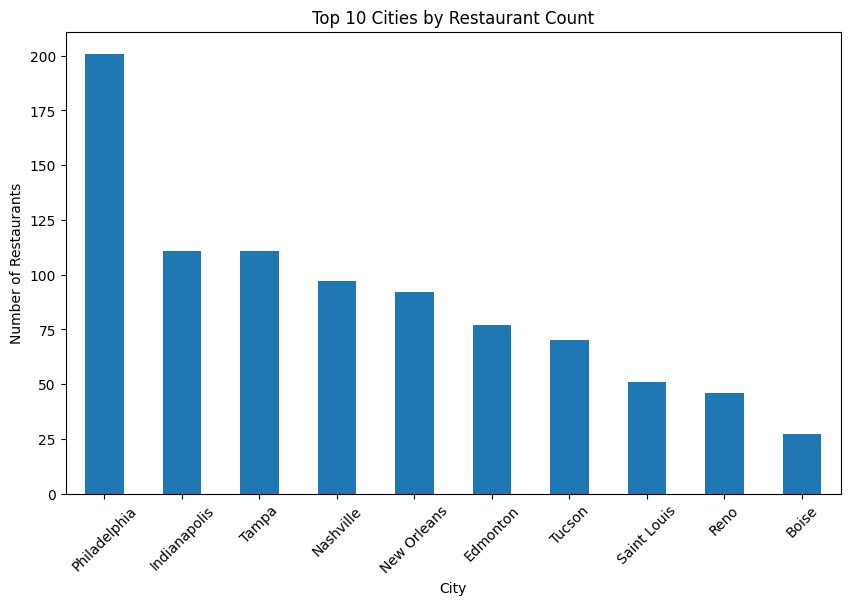

In [78]:
import matplotlib.pyplot as plt

top_cities = (
    restaurants_cleaned['city']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

top_cities.plot(kind='bar')

plt.title("Top 10 Cities by Restaurant Count")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=45)

plt.show()

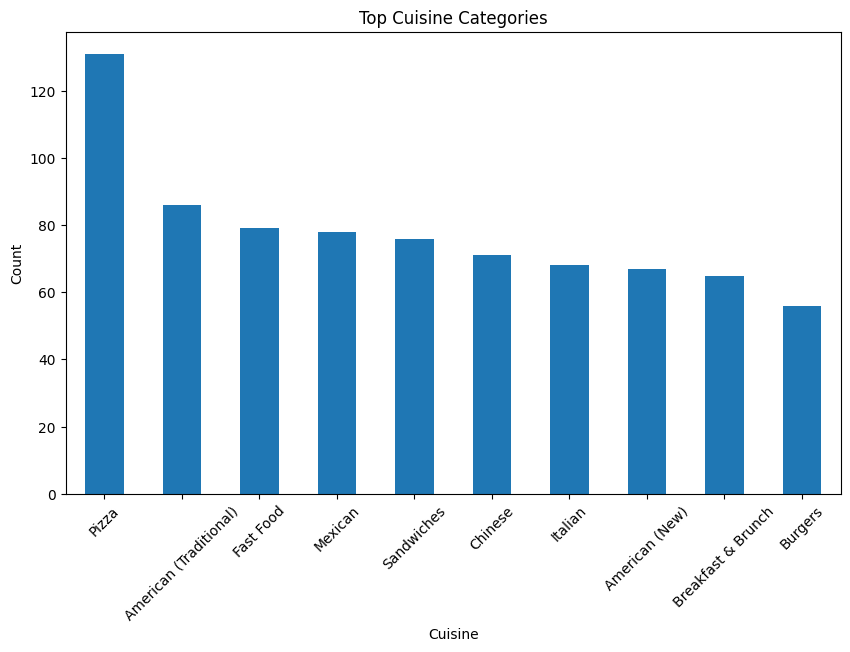

In [79]:
top_cuisines = (
    restaurants_cleaned['main_category']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

top_cuisines.plot(kind='bar')

plt.title("Top Cuisine Categories")
plt.xlabel("Cuisine")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

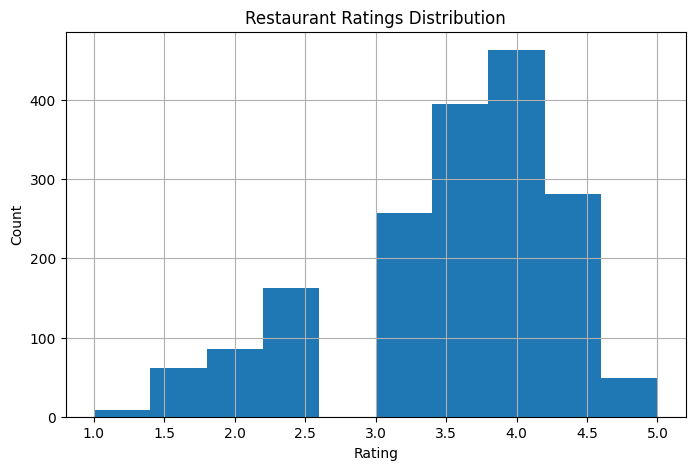

In [80]:
plt.figure(figsize=(8,5))

restaurants_cleaned['stars'].hist(bins=10)

plt.title("Restaurant Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

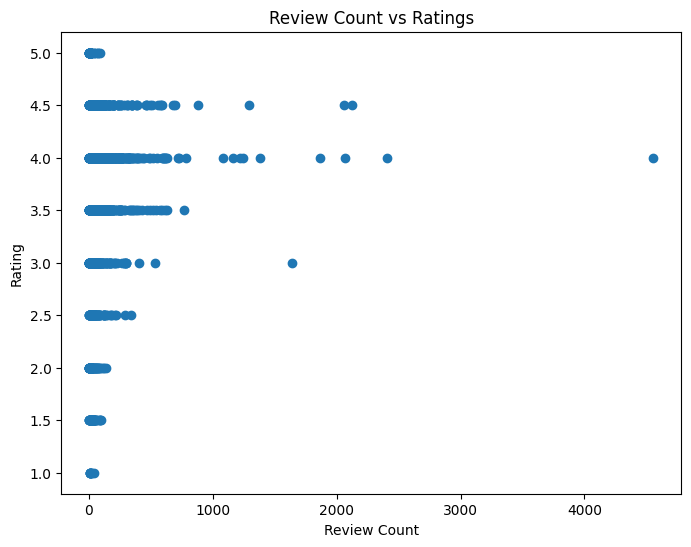

In [81]:
plt.figure(figsize=(8,6))

plt.scatter(
    restaurants_cleaned['review_count'],
    restaurants_cleaned['stars']
)

plt.xlabel("Review Count")
plt.ylabel("Rating")
plt.title("Review Count vs Ratings")

plt.show()

In [82]:
restaurants_cleaned['attributes'].iloc[0]

{'RestaurantsDelivery': 'False',
 'OutdoorSeating': 'False',
 'BusinessAcceptsCreditCards': 'False',
 'BusinessParking': "{'garage': False, 'street': True, 'validated': False, 'lot': False, 'valet': False}",
 'BikeParking': 'True',
 'RestaurantsPriceRange2': '1',
 'RestaurantsTakeOut': 'True',
 'ByAppointmentOnly': 'False',
 'WiFi': "u'free'",
 'Alcohol': "u'none'",
 'Caters': 'True'}

In [83]:
restaurants_cleaned['attributes'].head()

3     {'RestaurantsDelivery': 'False', 'OutdoorSeati...
5     {'BusinessParking': 'None', 'BusinessAcceptsCr...
8     {'Caters': 'True', 'Alcohol': 'u'full_bar'', '...
9     {'RestaurantsAttire': ''casual'', 'Restaurants...
11    {'Alcohol': ''none'', 'OutdoorSeating': 'None'...
Name: attributes, dtype: object

In [84]:
restaurants_cleaned['delivery'] = (
    restaurants_cleaned['attributes']
    .apply(
        lambda x: x.get('RestaurantsDelivery')
        if isinstance(x, dict)
        else None
    )
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_20492\1470506206.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  restaurants_cleaned['delivery'] = (


In [85]:
restaurants_cleaned['outdoor_seating'] = (
    restaurants_cleaned['attributes']
    .apply(
        lambda x: x.get('OutdoorSeating')
        if isinstance(x, dict)
        else None
    )
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_20492\1967970567.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  restaurants_cleaned['outdoor_seating'] = (


In [86]:
restaurants_cleaned['reservations'] = (
    restaurants_cleaned['attributes']
    .apply(
        lambda x: x.get('RestaurantsReservations')
        if isinstance(x, dict)
        else None
    )
)

In [87]:
restaurants_cleaned['wifi'] = (
    restaurants_cleaned['attributes']
    .apply(
        lambda x: x.get('WiFi')
        if isinstance(x, dict)
        else None
    )
)

In [88]:
restaurants_cleaned.groupby('delivery')['stars'].mean()

delivery
False    3.641248
None     3.786667
True     3.389529
Name: stars, dtype: float64

In [89]:
restaurants_cleaned.groupby('delivery')['stars'].mean()

delivery
False    3.641248
None     3.786667
True     3.389529
Name: stars, dtype: float64

In [90]:
restaurants_cleaned.groupby('outdoor_seating')['stars'].mean()

outdoor_seating
False    3.394558
None     3.907407
True     3.627837
Name: stars, dtype: float64

In [91]:
restaurants_cleaned.groupby('reservations')['stars'].mean()

reservations
False    3.383090
None     4.000000
True     3.633612
Name: stars, dtype: float64

In [92]:
restaurants_cleaned.groupby('main_category')['review_count'].mean().sort_values(ascending=False).head(10)

main_category
Live/Raw Food            2404.000000
German                   1563.333333
Brasseries               1245.000000
Jazz & Blues              619.000000
Donuts                    381.000000
Venues & Event Spaces     366.166667
Falafel                   345.000000
Cocktail Bars             319.692308
Herbs & Spices            295.000000
Cinema                    285.000000
Name: review_count, dtype: float64

In [93]:
restaurants_cleaned.groupby('main_category')['stars'].mean().sort_values(ascending=False).head(10)

main_category
Pets              5.00
Lebanese          5.00
Puerto Rican      5.00
Shaved Ice        4.75
Cheese Shops      4.50
Falafel           4.50
Food Stands       4.50
Gelato            4.50
Health Markets    4.50
Local Flavor      4.50
Name: stars, dtype: float64

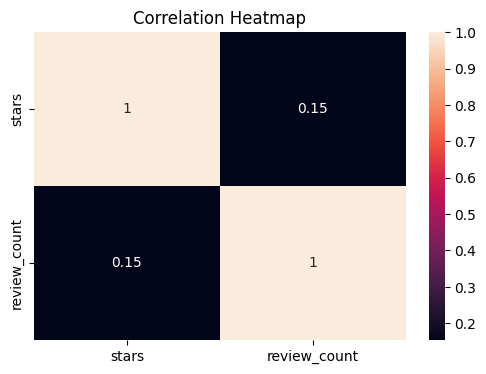

In [94]:
import seaborn as sns

correlation = restaurants_cleaned[
    ['stars', 'review_count']
].corr()

plt.figure(figsize=(6,4))

sns.heatmap(
    correlation,
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

In [95]:
final_df = restaurants_cleaned[
    [
        'business_id',
        'name',
        'city',
        'state',
        'stars',
        'review_count',
        'main_category',
        'delivery',
        'outdoor_seating',
        'reservations',
        'wifi'
    ]
].copy()

In [96]:
final_df.isnull().sum()

business_id          0
name                 0
city                 0
state                0
stars                0
review_count         0
main_category        0
delivery           155
outdoor_seating    312
reservations       321
wifi               503
dtype: int64

In [97]:
final_df['delivery'] = final_df['delivery'].fillna('False')
final_df['outdoor_seating'] = final_df['outdoor_seating'].fillna('False')
final_df['reservations'] = final_df['reservations'].fillna('False')
final_df['wifi'] = final_df['wifi'].fillna('no')

In [98]:
final_df.to_csv(
    "../data/processed/final_restaurant_data.csv",
    index=False
)

In [99]:
def recommend_restaurants(
    cuisine,
    city=None,
    min_rating=4.0
):

    filtered = final_df[
        (final_df['main_category']
         .str.contains(cuisine, case=False, na=False))
        &
        (final_df['stars'] >= min_rating)
    ]

    if city:
        filtered = filtered[
            filtered['city']
            .str.contains(city, case=False, na=False)
        ]

    recommendations = filtered.sort_values(
        by=['stars', 'review_count'],
        ascending=False
    )

    return recommendations[
        [
            'name',
            'city',
            'main_category',
            'stars',
            'review_count'
        ]
    ].head(10)

In [100]:
recommend_restaurants("Pizza")

,name,city,main_category,stars,review_count
4217,Pizzeria Maki,Greenville,Pizza,5.0,13
1116,Paola's Pizzeria,Wayne,Pizza,4.5,126
2082,Alfredo's Pizza,Broomall,Pizza,4.5,79
3828,Gasparilla Pizzeria & Growlers,Valrico,Pizza,4.5,57
3898,Ramble Pizza,Philadelphia,Pizza,4.5,19
4233,Sam's Pizza and Donair,Edmonton,Pizza,4.5,19
3483,Pizza In & Go,Antioch,Pizza,4.5,16
4360,Dough Boy Pizza,Philadelphia,Pizza,4.5,11
4202,HotBox Pizza,Fishers,Pizza,4.5,7
1294,Eh! Formaggio,Indianapolis,Pizza,4.5,6


In [101]:
recommend_restaurants(
    cuisine="Mexican",
    city="Philadelphia",
    min_rating=4
)

,name,city,main_category,stars,review_count
2057,México Lindo,Philadelphia,Mexican,4.5,73
4980,SET NoLibs,Philadelphia,Mexican,4.0,108
3477,Los Compadres,Philadelphia,Mexican,4.0,12
4624,4 Seasons Grill Mexican Restaurant,Philadelphia,Mexican,4.0,12


In [102]:
final_df['combined_features'] = (
    final_df['main_category'].astype(str)
    + " "
    + final_df['city'].astype(str)
    + " "
    + final_df['delivery'].astype(str)
    + " "
    + final_df['wifi'].astype(str)
)

In [103]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(
    final_df['combined_features']
)

In [104]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)

In [105]:
def get_similar_restaurants(restaurant_name):

    idx = final_df[
        final_df['name'] == restaurant_name
    ].index[0]

    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:11]

    restaurant_indices = [
        i[0]
        for i in similarity_scores
    ]

    return final_df.iloc[
        restaurant_indices
    ][
        [
            'name',
            'main_category',
            'city',
            'stars'
        ]
    ]

In [106]:
final_df = final_df.reset_index(drop=True)

In [107]:
final_df['combined_features'] = (
    final_df['main_category'].astype(str)
    + " "
    + final_df['city'].astype(str)
    + " "
    + final_df['delivery'].astype(str)
    + " "
    + final_df['wifi'].astype(str)
)

In [108]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(
    final_df['combined_features']
)

In [109]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix)

In [110]:
def get_similar_restaurants(restaurant_name):

    matches = final_df[
        final_df['name'].str.lower() == restaurant_name.lower()
    ]

    if matches.empty:
        return "Restaurant not found."

    idx = matches.index[0]

    similarity_scores = list(
        enumerate(cosine_sim[idx])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:11]

    restaurant_indices = [
        i[0]
        for i in similarity_scores
    ]

    return final_df.iloc[
        restaurant_indices
    ][
        [
            'name',
            'main_category',
            'city',
            'stars'
        ]
    ]

In [111]:
get_similar_restaurants("Lucky Dogs")

,name,main_category,city,stars
811,The Wacked Out Weiner New Orleans,Hot Dogs,New Orleans,4.5
12,Super Dog,Hot Dogs,Nashville,4.0
1614,Wendy's,Hot Dogs,Reno,1.5
1299,Skyline Chili,Hot Dogs,Clearwater,4.0
543,Burger King,Hot Dogs,Metairie,1.5
935,Pop Inn,Hot Dogs,Chalfont,3.5
1398,Coney Island,Hot Dogs,Zephyrhills,3.5
1108,Home Depot Hot Dog Cart,Hot Dogs,King of Prussia,4.0
1637,Cafe Nino,Pizza,New Orleans,4.0
82,Eat Mah Taco @ Pal's Lounge,American (New),New Orleans,4.5


In [112]:
test_df = pd.read_csv(
    "../data/processed/final_restaurant_data.csv"
)

test_df.head()

,business_id,name,city,state,stars,review_count,main_category,delivery,outdoor_seating,reservations,wifi
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,Philadelphia,PA,4.0,80,Bubble Tea,False,False,False,u'free'
1,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,Ashland City,TN,2.0,6,Burgers,True,True,False,u'no'
2,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,Affton,MO,3.0,19,Pubs,False,True,False,u'free'
3,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,Nashville,TN,1.5,10,Ice Cream & Frozen Yogurt,True,True,False,u'no'
4,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,Tampa Bay,FL,4.0,10,Vietnamese,False,NaN,False,no


In [113]:
final_df.columns

Index(['business_id', 'name', 'city', 'state', 'stars', 'review_count',
       'main_category', 'delivery', 'outdoor_seating', 'reservations', 'wifi',
       'combined_features'],
      dtype='object')

In [114]:
final_df = restaurants_cleaned[
    [
        'business_id',
        'name',
        'city',
        'state',
        'stars',
        'review_count',
        'main_category',
        'delivery',
        'outdoor_seating',
        'reservations',
        'wifi',
        'latitude',
        'longitude'
    ]
].copy()

In [115]:
final_df.to_csv(
    "../data/processed/final_restaurant_data.csv",
    index=False
)